In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text 
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.preprocessing import MultiLabelBinarizer
import re 
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from huggingface_hub import snapshot_download
from transformers import AutoModelForSequenceClassification, AutoTokenizer


c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_admits = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\diagnoses_icd.csv.gz', compression='gzip')
df_transfers = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar.csv.gz', compression='gzip')

In [ ]:
df_admits = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\diagnoses_icd.csv.gz', compression='gzip')
#df_transfers = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar.csv.gz', compression='gzip')

In [ ]:
#print(df_admits.head(10))
#print(df_diagnosis.head(10))
#print(df_icd_proc.head(10))
#print(df_icd_diagnosis.head(10))
df_pat.head(10)

In [ ]:
# Data Checks

#df_admits.isna().any() # check which columns have NaN
df_admits.loc[:,df_admits.isna().any()]
#df_admits[df_admits['admission_location'] == '']
#pd.reset_option('display.max_rows')


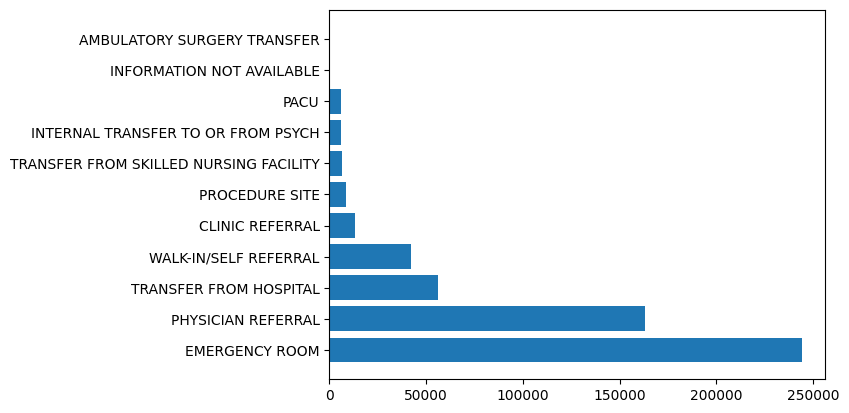

In [3]:
plt.barh(df_admits['admission_location'].value_counts().index,df_admits.admission_location.value_counts().values)
plt.show() # to check for missing values 

In [27]:
# Join diagnosis, admissions and procs
df_admit_icd = pd.merge(df_admits,df_diagnosis,how = 'left', on = 'hadm_id')
df_admit_diagnosis = pd.merge(df_admit_icd,df_icd_diagnosis,how = 'left', on = 'icd_code')
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_icd_proc,how = 'left', on = 'icd_code')
df_admit_diagnosis.drop(columns= ['subject_id_y'], inplace = True)
df_admit_diagnosis.rename(columns={'long_title_x': 'icd_diagnosis_name','long_title_y':'proc_name','subject_id_x':'subject_id'}, inplace=True)
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_pat[['subject_id', 'anchor_age','gender']],how = 'left', on = 'subject_id')

In [28]:
# Replace all NaN with 'No Diagnosis'
df_admit_diagnosis['icd_diagnosis_name'] = df_admit_diagnosis['icd_diagnosis_name'].fillna('No Diagnosis')
df_admit_diagnosis['proc_name'] = df_admit_diagnosis['proc_name'].fillna('No Procedure')
df_admit_diagnosis['icd_code'] = df_admit_diagnosis['icd_code'].fillna('No ICD Code')
df_admit_diagnosis[df_admit_diagnosis['proc_name'].isna()]

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,hospital_expire_flag,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender


In [29]:
icd_counts = df_admit_diagnosis.icd_code.value_counts()

# Get the top 100 ICD codes by frequency
top_100_icd = df_admit_diagnosis['icd_code'].value_counts().nlargest(101).index

# Map ICD codes — keep top 100, replace others with 'Other Code'
df_admit_diagnosis['icd_code_converted'] = df_admit_diagnosis['icd_code'].apply(
    lambda x: str(x) if x in top_100_icd else 'Other Code'
)

df_admit_diagnosis.drop(columns = ['icd_version_y','icd_version_x','edregtime','edouttime','deathtime','admit_provider_id','hospital_expire_flag',
                                          'seq_num','icd_code','language','icd_version'],inplace = True)

In [30]:
pd.set_option('display.max_rows', 10000)    
print(df_admit_diagnosis.icd_code_converted.value_counts().head(10000))

icd_code_converted
Other Code    4222349
4019           102368
E785            84570
I10             83775
2724            67293
Z87891          62806
K219            56157
53081           48628
25000           43077
F329            41876
I2510           41550
F419            38911
42731           37070
4280            36606
311             36349
41401           36083
N179            35884
Z20822          33113
V1582           31705
Z7901           30957
5849            29136
2449            28521
E039            28000
Z794            27642
E119            26266
3051            25879
2859            24395
F17210          24106
G4733           23933
40390           23831
V5861           22635
30000           22399
E669            22004
V270            21238
D649            21137
I4891           21022
J45909          20679
5990            20387
Z7902           19961
2720            19880
Y929            19830
49390           19703
V5867           19600
D62             19356
Z66          

In [26]:
df_admit_diagnosis.head()

,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,marital_status,race,icd_diagnosis_name,proc_name,anchor_age,gender,icd_code_converted
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,Portal hypertension,No Procedure,52,F,Other Code
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,Other ascites,No Procedure,52,F,Other Code
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,Cirrhosis of liver without mention of alcohol,No Procedure,52,F,Other Code
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,Unspecified viral hepatitis C without hepatic ...,No Procedure,52,F,Other Code
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,"Chronic airway obstruction, not elsewhere clas...",Excision of anus,52,F,496


In [31]:
# Group first to reduce data size
df_admit_diagnosis_grouped = df_admit_diagnosis.groupby(['hadm_id', 'subject_id']).agg({  
     'admission_type':'first',
     'admission_location': 'first',
     'discharge_location':'first',
     'admittime':'first',
     'dischtime':'first',
     'insurance':'first',
     'marital_status': 'first',
     'race':'first',
     'anchor_age': 'first',
     'gender':'first',
     'icd_code_converted': lambda x: set(x),
     'icd_diagnosis_name': lambda x: set(x),
     'proc_name': lambda x: set(x),
     }).reset_index()
df_admit_diagnosis_grouped.head(5)  

,hadm_id,subject_id,admission_type,admission_location,discharge_location,admittime,dischtime,insurance,marital_status,race,anchor_age,gender,icd_code_converted,icd_diagnosis_name,proc_name
0,20000019,10467237,EW EMER.,EMERGENCY ROOM,HOME,2159-03-20 21:08:00,2159-03-23 16:54:00,Medicaid,SINGLE,HISPANIC/LATINO - GUATEMALAN,76,F,"{2724, 2761, 5849, Other Code, 25000, 49390, 4...","{Anemia, unspecified, Family history of malign...","{Suture of laceration of palate, Biopsy of mou..."
1,20000024,16925328,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,2151-05-25 21:44:00,2151-05-26 18:36:00,Medicare,SINGLE,WHITE,84,F,"{I10, Other Code}","{Legal blindness, as defined in USA, Deficienc...",{No Procedure}
2,20000034,19430048,DIRECT OBSERVATION,PHYSICIAN REFERRAL,None,2174-05-22 19:13:00,2174-05-24 17:27:00,Medicare,SINGLE,BLACK/CARIBBEAN ISLAND,72,M,"{Z86718, Z8673, E1122, N400, E871, G4700, Othe...","{Other chronic pancreatitis, Alcoholic cirrhos...",{Physical Rehabilitation and Diagnostic Audiol...
3,20000041,18910522,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,2143-09-03 07:15:00,2143-09-06 13:50:00,Private,SINGLE,WHITE,62,F,"{V1251, 2724, 27800, Other Code, 4019, 53081}",{Personal history of venous thrombosis and emb...,"{Biopsy of mouth, unspecified structure, No Pr..."
4,20000045,13413708,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,2138-05-21 16:25:00,2138-05-29 02:05:00,Private,DIVORCED,WHITE,51,F,"{Z87891, E8339, Other Code, N390}","{Neoplasm related pain (acute) (chronic), Seco...",{No Procedure}


In [32]:
# Assign admission ranks throughout time
# Readmission is within 30 days of discharge and next admission so insert flag

df_admit_diagnosis_grouped['admittime'] = pd.to_datetime(df_admit_diagnosis_grouped['admittime'])
df_admit_diagnosis_grouped['dischtime'] = pd.to_datetime(df_admit_diagnosis_grouped['dischtime'])

df_admit_diagnosis_grouped['admission_rank'] = df_admit_diagnosis_grouped.groupby('subject_id')['admittime'].rank(method='dense', ascending=True)
df_admit_diagnosis_grouped.sort_values(by = ['admission_rank'],ascending= True, inplace= True)
# Get next admission's out time for each patient
df_admit_diagnosis_grouped['last_dischtime'] = df_admit_diagnosis_grouped.groupby('subject_id')['dischtime'].shift(1)

# Calculate days until next visit
df_admit_diagnosis_grouped['days_from_last'] = (df_admit_diagnosis_grouped['admittime'] - df_admit_diagnosis_grouped['last_dischtime']).dt.days

# Create readmission flag (1 if last visit is within 30 days, else 0)
df_admit_diagnosis_grouped['readmission'] = df_admit_diagnosis_grouped['days_from_last'].apply(lambda x: 1 if pd.notnull(x) and x <= 30 and x >= 0 else 0)

#df_admit_diagnosis_grouped[df_admit_diagnosis_grouped['subject_id'] == 10000032]

In [34]:
# label encode the text columns
df_admit_diagnosis_encoded = df_admit_diagnosis_grouped.drop(columns= ['admittime','dischtime','last_dischtime','days_from_last', 
                                                                       'admission_rank','icd_diagnosis_name','proc_name']) # drop irrelevant cols

cols_to_encode = ['admission_type','admission_location','discharge_location','insurance','race','gender','marital_status']
label_encoder = preprocessing.LabelEncoder()
for col in cols_to_encode:
    df_admit_diagnosis_encoded[col] = label_encoder.fit_transform(df_admit_diagnosis_encoded[col])
df_admit_diagnosis_encoded[df_admit_diagnosis_encoded['subject_id'] == 10000032]


,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,icd_code_converted,readmission
141961,22595853,10000032,8,8,6,0,3,28,52,0,"{Other Code, 496, V1582}",0
155119,22841357,10000032,5,2,6,0,3,28,52,0,"{2761, Other Code, 496, 3051}",0
495453,29079034,10000032,5,2,6,0,3,28,52,0,"{V4986, 3051, 496, 2761, Other Code}",1
313493,25742920,10000032,5,2,8,0,3,28,52,0,"{2761, Other Code, 496, 3051}",1


In [35]:
mlb = MultiLabelBinarizer(sparse_output=True)
X = mlb.fit_transform(df_admit_diagnosis_encoded['icd_code_converted'])

df_icd_encoded = pd.DataFrame.sparse.from_spmatrix(
    X,
    index=df_admit_diagnosis_encoded['hadm_id'],
    columns=mlb.classes_
)

In [43]:
df_admit_diagnosis_icd_encoded = pd.merge(
    df_admit_diagnosis_encoded,
    df_icd_encoded,
    on='hadm_id'
)
df_admit_diagnosis_icd_encoded.drop(columns=['Other Code','icd_code_converted'], inplace=True)

In [44]:
pd.set_option('display.max_columns', None)
df_admit_diagnosis_icd_encoded.head()

,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,readmission,2449,25000,2720,2724,2749,2761,27651,27800,2851,2859,30000,30500,3051,311,32723,33829,4019,40390,412,41400,41401,42731,4280,486,49390,496,53081,5849,5859,5990,60000,73300,78650,D509,D62,D649,D696,E039,E1122,E1165,E119,E669,E785,E8339,E8342,E871,E872,E875,E876,E8889,F17210,F329,F419,G4700,G4733,G8929,I10,I110,I129,I130,I2510,I252,I480,I4891,I5032,J449,J45909,J9601,K219,K5900,M109,N179,N189,N390,N400,V103,V1251,V1254,V153,V1582,V270,V4364,V4581,V4582,V4986,V5861,V5866,V5867,Y92230,Y929,Z20822,Z515,Z66,Z7901,Z7902,Z794,Z86718,Z8673,Z87891,Z951,Z955
0,20001596,15327072,4,10,13,3,1,7,65,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,20001633,18030855,5,2,6,0,2,28,28,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,20001747,12270767,6,8,7,1,1,28,91,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
3,20001770,10117812,5,10,11,0,2,28,35,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,20001800,11828074,4,2,13,4,1,28,59,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [45]:
print("Length of Original Data: ",len(df_admit_diagnosis_encoded))
print("Length of Data After MLB: ",len(df_admit_diagnosis_icd_encoded))

Length of Original Data:  546028
Length of Data After MLB:  546028


Medication Data

In [46]:
df_medi.drop(columns = ['enter_provider_id','charttime','scheduletime','storetime','emar_id','emar_seq','poe_id','pharmacy_id','enter_provider_id'
                        ,'charttime','scheduletime','storetime'], inplace= True)
df_medi['medication'] = df_medi['medication'].fillna('No Medication')
df_medi.head(5)

,subject_id,hadm_id,medication,event_txt
0,10000032,22595853.0,Heparin,Administered
1,10000032,22595853.0,Raltegravir,Administered
2,10000032,22595853.0,Sodium Chloride 0.9% Flush,Flushed
3,10000032,22595853.0,Nicotine Patch,Not Applied
4,10000032,22595853.0,Furosemide,Not Given


In [47]:
# Define grouping rules for usage
administered = [
    'Administered', 'Partial Administered', 'Applied',
    'Confirmed', 'Started', 'Administered in Other Location',
    'Started in Other Location', 'Administered Bolus from IV Drip',
    'Applied in Other Location', 'Removed Existing / Applied New',
    'Removed Existing / Applied New in Other Location',
    'Restarted', 'Restarted in Other Location'
]

not_administered = [
    'Not Applied', 'Not Given', 'Not Flushed', 'Hold Dose', 'Removed',
    'Not Confirmed', 'Not Started', 'Not Assessed', 'Not Removed',
    'Not Stopped', 'Not Read', 'Not Given per Sliding Scale',
    'Not Stopped per Sliding Scale', 'Not Started per Sliding Scale',
    'Not Given per Sliding Scale in Other Location', 'Read', 'Read in Other Location', 'Stopped', 'Stopped As Directed',
    'Stopped - Unscheduled', 'Stopped - Unscheduled in Other Location',
    'Rate Change', 'Rate Change in Other Location','Removed in Other Location',
    'Confirmed in Other Location'

]

delayed = [s for s in df_medi['event_txt'].dropna().unique() if s.startswith('Delayed')]

other = [
    'Flushed', 'Flushed in Other Location', 'Assessed',
    'Assessed in Other Location', 'Infusion Reconciliation',
    'Infusion Reconciliation Not Done', 'Pain score re-assessment',
    'Pain score re-assess not done', 'Documented in O.R. Holding',
    'TPN Rate Not Changed', ' in Other Location', 'Partial ',
]

In [48]:
# Make sure event lists are sets for faster lookup
administered_set = set(administered)
not_administered_set = set(not_administered)
delayed_set = set(delayed)

# Initialize with 'Other'
df_medi['usage'] = 'Other'

# Apply conditions using boolean indexing
mask_admin = df_medi['event_txt'].isin(administered_set) & (df_medi['medication'] != 'No Medication')
mask_not_admin = df_medi['event_txt'].isin(not_administered_set)
mask_delayed = df_medi['event_txt'].isin(delayed_set)

df_medi.loc[mask_admin, 'usage'] = 'Administered'
df_medi.loc[mask_not_admin, 'usage'] = 'Not Administered'
df_medi.loc[mask_delayed, 'usage'] = 'Delayed'

# Filter to only include 'Administered'
df_medi = df_medi[df_medi['usage'] == 'Administered']
df_medi['medication'] = df_medi['medication'].str.lower()

In [49]:
df_medi[df_medi['usage']=='Administered']

,subject_id,hadm_id,medication,event_txt,usage
0,10000032,22595853.0,heparin,Administered,Administered
1,10000032,22595853.0,raltegravir,Administered,Administered
7,10000032,22595853.0,albuterol inhaler,Administered,Administered
8,10000032,22595853.0,furosemide,Administered,Administered
9,10000032,22595853.0,spironolactone,Administered,Administered
...,...,...,...,...,...
42808584,19999828,29734428.0,lorazepam,Administered,Administered
42808585,19999828,29734428.0,insulin,Administered,Administered
42808588,19999828,NaN,morphine sulfate,Administered,Administered
42808590,19999828,NaN,ondansetron,Administered,Administered


In [ ]:
# Step 1: Get the top 100 medications by frequency
top_100_meds = df_medi['medication'].value_counts().nlargest(101).index

# Step 2: Replace all non-top-100 medications with 'Other'
df_medi['medication_grouped'] = df_medi['medication'].apply(
    lambda x: str(x) if x in top_100_meds else 'Other Medication'
)

In [54]:
# Group first to reduce data size
df_medi.drop(columns=['medication','event_txt','usage'],inplace=True)

df_medi_grouped = df_medi.groupby(['hadm_id', 'subject_id']).agg({  
     'medication_grouped': lambda x: set(x),
     }).reset_index()
df_medi_grouped.head(5)  

,hadm_id,subject_id,medication_grouped
0,20000024.0,16925328,"{gabapentin, acetaminophen, oxycodone (immedia..."
1,20000034.0,19430048,"{folic acid, Other Medication, sodium bicarbon..."
2,20000045.0,13413708,"{bisacodyl, metronidazole, cefepime, acetamino..."
3,20000147.0,14990224,"{simethicone, polyethylene glycol, senna, furo..."
4,20000180.0,15296741,"{bisacodyl, ondansetron, gabapentin, Other Med..."


In [60]:
mlb = MultiLabelBinarizer(sparse_output=True)
X = mlb.fit_transform(df_medi_grouped['medication_grouped'])

df_medi_encoded = pd.DataFrame.sparse.from_spmatrix(
    X,
    index=df_medi_grouped['hadm_id'],
    columns=mlb.classes_
)

In [63]:
df_medi_encoded.drop(columns=['Other Medication'], inplace=True)

In [64]:
df_medi_encoded.head()

,acetaminophen,acetaminophen iv,acyclovir,albuterol 0.083% neb soln,albuterol inhaler,allopurinol,amiodarone,amlodipine,ampicillin-sulbactam,apixaban,aspirin,atorvastatin,benzonatate,bisacodyl,calcium carbonate,carvedilol,cefazolin,cefepime,ceftriaxone,chlorhexidine gluconate 0.12% oral rinse,ciprofloxacin hcl,clonazepam,clopidogrel,cyanocobalamin,dexamethasone,diltiazem,diphenhydramine,docusate sodium,enoxaparin (prophylaxis),enoxaparin sodium,famotidine,fentanyl citrate,ferrous sulfate,fluticasone-salmeterol diskus (250/50),folic acid,furosemide,gabapentin,guaifenesin,heparin,hydralazine,hydromorphone (dilaudid),ibuprofen,insulin,ipratropium bromide neb,ipratropium-albuterol neb,ketorolac,labetalol,lactulose,levetiracetam,levothyroxine sodium,lidocaine 5% patch,lisinopril,lorazepam,magnesium oxide,magnesium sulfate,meropenem,metoclopramide,metoprolol succinate xl,metoprolol tartrate,metronidazole,midodrine,morphine sulfate,multivitamins,multivitamins w/minerals,neutra-phos,norepinephrine,nystatin oral suspension,omeprazole,ondansetron,oxycodone (immediate release),oxycodone (immediate release),pantoprazole,piperacillin-tazobactam,polyethylene glycol,potassium chloride,prednisone,pregabalin,propofol,quetiapine fumarate,ramelteon,ranitidine,rifaximin,senna,sertraline,sevelamer carbonate,simethicone,sodium bicarbonate,spironolactone,sucralfate,tacrolimus,tamsulosin,thiamine,torsemide,tramadol,trazodone,ursodiol,vancomycin,vancomycin oral liquid,vitamin d,warfarin
hadm_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
20000024.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
20000034.0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0
20000045.0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
20000147.0,1,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
20000180.0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0


In [65]:
df_full_dataset = pd.merge(
    df_admit_diagnosis_icd_encoded,
    df_medi_encoded,
    how='left',
    on='hadm_id'
)
df_full_dataset.fillna(0, inplace=True)

In [66]:
df_full_dataset

,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,readmission,2449,25000,2720,2724,2749,2761,27651,27800,2851,2859,30000,30500,3051,311,32723,33829,4019,40390,412,41400,41401,42731,4280,486,49390,496,53081,5849,5859,5990,60000,73300,78650,D509,D62,D649,D696,E039,E1122,E1165,E119,E669,E785,E8339,E8342,E871,E872,E875,E876,E8889,F17210,F329,F419,G4700,G4733,G8929,I10,I110,I129,I130,I2510,I252,I480,I4891,I5032,J449,J45909,J9601,K219,K5900,M109,N179,N189,N390,N400,V103,V1251,V1254,V153,V1582,V270,V4364,V4581,V4582,V4986,V5861,V5866,V5867,Y92230,Y929,Z20822,Z515,Z66,Z7901,Z7902,Z794,Z86718,Z8673,Z87891,Z951,Z955,acetaminophen,acetaminophen iv,acyclovir,albuterol 0.083% neb soln,albuterol inhaler,allopurinol,amiodarone,amlodipine,ampicillin-sulbactam,apixaban,aspirin,atorvastatin,benzonatate,bisacodyl,calcium carbonate,carvedilol,cefazolin,cefepime,ceftriaxone,chlorhexidine gluconate 0.12% oral rinse,ciprofloxacin hcl,clonazepam,clopidogrel,cyanocobalamin,dexamethasone,diltiazem,diphenhydramine,docusate sodium,enoxaparin (prophylaxis),enoxaparin sodium,famotidine,fentanyl citrate,ferrous sulfate,fluticasone-salmeterol diskus (250/50),folic acid,furosemide,gabapentin,guaifenesin,heparin,hydralazine,hydromorphone (dilaudid),ibuprofen,insulin,ipratropium bromide neb,ipratropium-albuterol neb,ketorolac,labetalol,lactulose,levetiracetam,levothyroxine sodium,lidocaine 5% patch,lisinopril,lorazepam,magnesium oxide,magnesium sulfate,meropenem,metoclopramide,metoprolol succinate xl,metoprolol tartrate,metronidazole,midodrine,morphine sulfate,multivitamins,multivitamins w/minerals,neutra-phos,norepinephrine,nystatin oral suspension,omeprazole,ondansetron,oxycodone (immediate release),oxycodone (immediate release),pantoprazole,piperacillin-tazobactam,polyethylene glycol,potassium chloride,prednisone,pregabalin,propofol,quetiapine fumarate,ramelteon,ranitidine,rifaximin,senna,sertraline,sevelamer carbonate,simethicone,sodium bicarbonate,spironolactone,sucralfate,tacrolimus,tamsulosin,thiamine,torsemide,tramadol,trazodone,ursodiol,vancomycin,vancomycin oral liquid,vitamin d,warfarin
0,20001596,15327072,4,10,13,3,1,7,65,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,20001633,18030855,5,2,6,0,2,28,28,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,20001747,12270767,6,8,7,1,1,28,91,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,1.0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,1.0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,20001770,10117812,5,10,11,0,2,28,35,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,0,0,1.0,0,0,0,0,1.0,1.0,0,0,1.0,0,0,0,0,1.0,1.0,1.0,0,0,0,1.0,1.0,1.0,1.0,1.0,0,1.0,0,0,0,1.0,1.0,0,1.0,0,0,1.0,0,0,0,1.0,0,0,0,0,0,0,0,1.0,0,0,0,0,1.

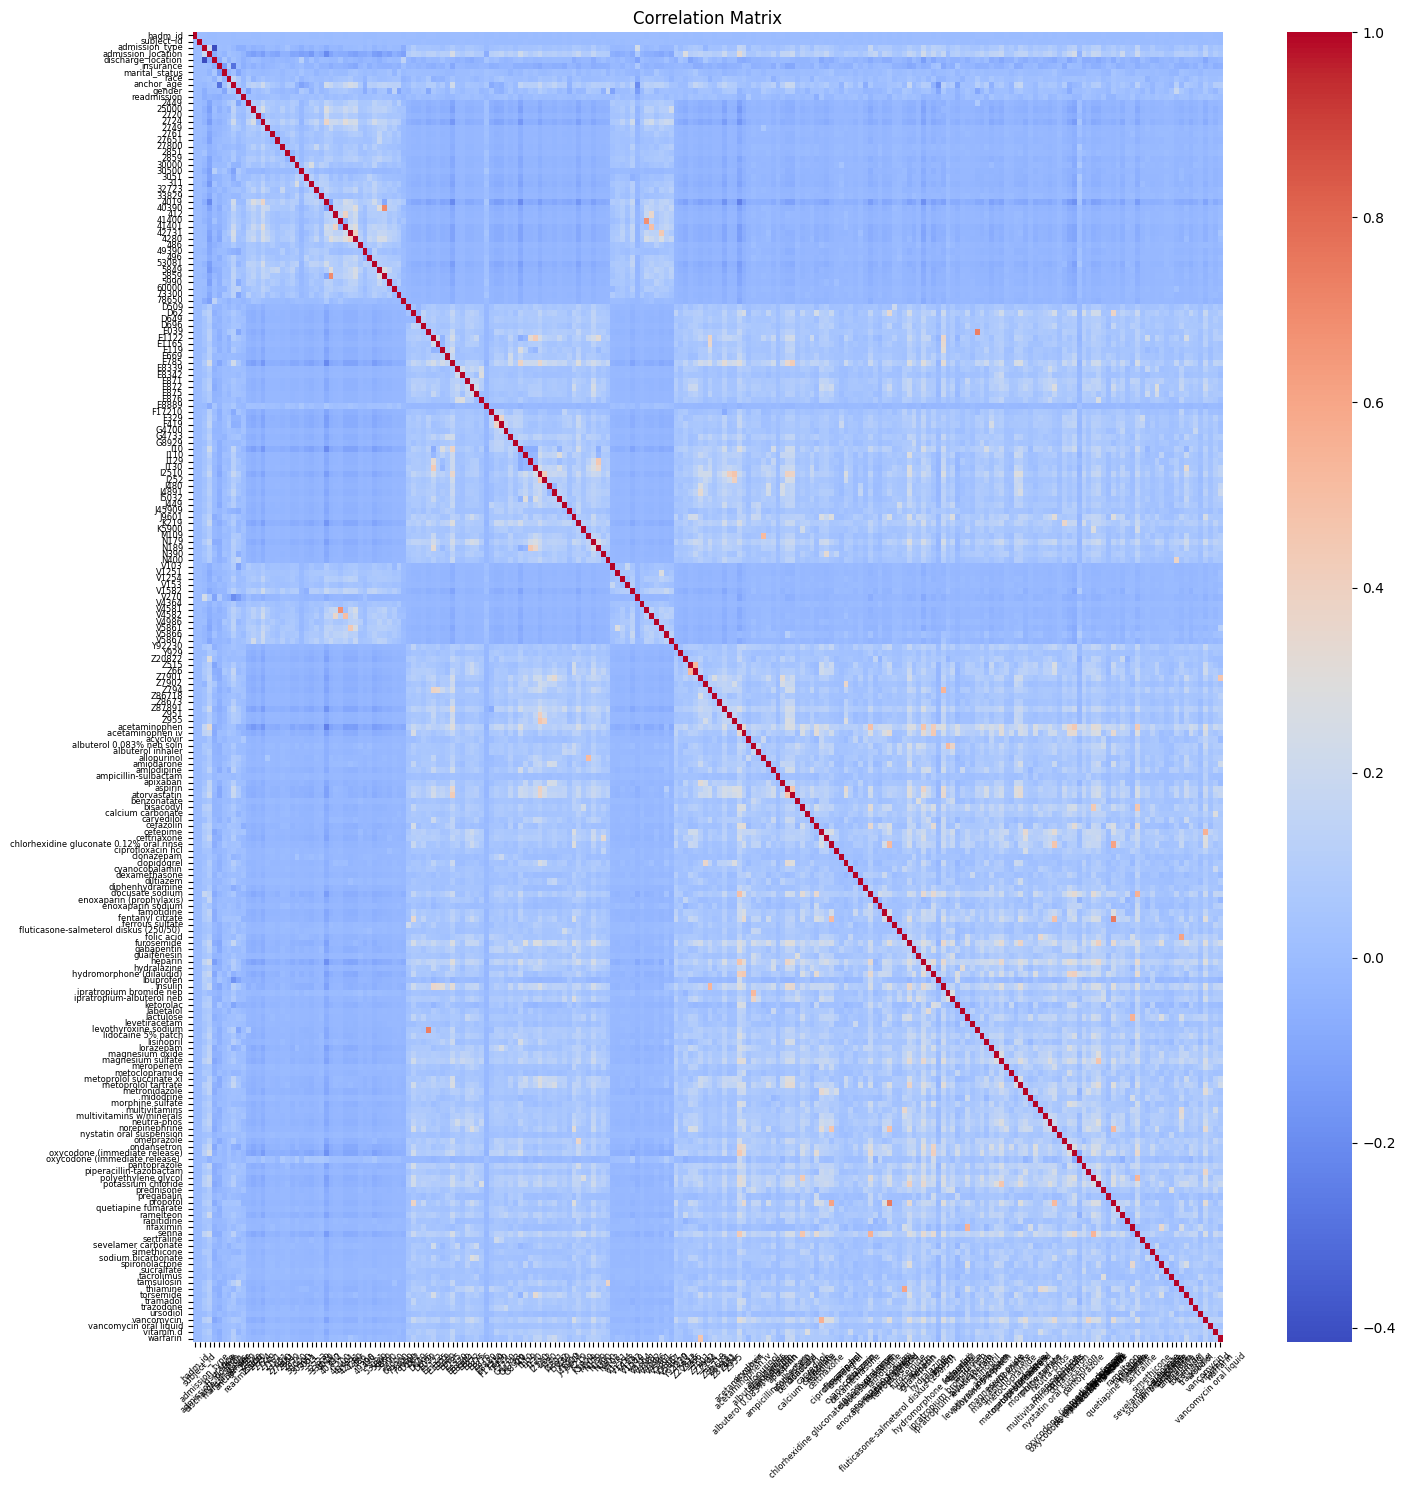

In [68]:
# Correlation matrix
corr_matrix = df_full_dataset.corr()

plt.figure(figsize=(15, 15))

sns.heatmap(
    corr_matrix,
    annot=False,  # Turn off annotation values
    cmap='coolwarm',
    xticklabels=corr_matrix.columns,
    yticklabels=corr_matrix.columns
)

plt.title("Correlation Matrix")

# Make axis label text small
plt.xticks(rotation=45, fontsize=6)
plt.yticks(rotation=0, fontsize=6)

plt.tight_layout()
plt.show()


In [71]:
# Get correlations with the target variable
target_corr = df_full_dataset.corr()['readmission'].drop('readmission')

# Filter for absolute correlations above 0.2
important_factors = target_corr[abs(target_corr) > 0.02]

# Optional: Sort them by strength
important_factors = important_factors.sort_values(ascending=False)

print(important_factors)


acyclovir                   0.066500
vancomycin oral liquid      0.048893
rifaximin                   0.046903
lorazepam                   0.044781
cefepime                    0.044071
4280                        0.043607
V1251                       0.041850
multivitamins w/minerals    0.040754
ursodiol                    0.039044
tacrolimus                  0.038842
gender                      0.038025
Z515                        0.036725
Z86718                      0.036716
meropenem                   0.036394
33829                       0.034863
folic acid                  0.034603
G4700                       0.033918
sodium bicarbonate          0.033780
pantoprazole                0.033735
prednisone                  0.033008
5849                        0.032803
midodrine                   0.032098
lactulose                   0.032030
V5867                       0.031314
V5861                       0.031195
dexamethasone               0.030836
2761                        0.030835
K

In [1]:
# test